# CardioVision AI — Parte 2B: Transfer Learning com ResNet50

Classificação de ECGs usando **Transfer Learning** com ResNet50 pré-treinado em ImageNet.

**Pré-requisito:** executar o notebook `01_preprocessing.ipynb` primeiro.

In [9]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model


@tf.keras.utils.register_keras_serializable(package="CardioVision")
class ResNet50Preprocess(tf.keras.layers.Layer):
    """Camada serializável para pré-processamento ImageNet do ResNet50."""

    def call(self, inputs):
        return preprocess_input(inputs)

## 1. Carregar conjuntos pré-processados

In [10]:

PROCESSED_PATH = Path("../data/processed")
METADATA_PATH = PROCESSED_PATH / "metadata.json"
MODELS_PATH = Path("../trained_models")
MODELS_PATH.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

with open(METADATA_PATH, encoding="utf-8") as f:
    metadata = json.load(f)

class_names = metadata["class_names"]
num_classes = len(class_names)

print(f"Classes ({num_classes}): {class_names}")
print(f"Split — treino: {metadata['counts']['train']} | "
      f"validação: {metadata['counts']['validation']} | "
      f"teste: {metadata['counts']['test']}")

train_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_PATH / "train",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_PATH / "validation",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_PATH / "test",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Classes (4): ['batimento_cardiaco_anormal', 'historico_pos_infarto', 'infarto_do_miocardio', 'normal']
Split — treino: 649 | validação: 139 | teste: 140
Found 649 files belonging to 4 classes.
Found 139 files belonging to 4 classes.
Found 140 files belonging to 4 classes.


In [11]:

def collect_labels_and_predictions(dataset, model):
    y_true = np.concatenate([y.numpy() for _, y in dataset], axis=0)
    y_prob = model.predict(dataset, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    return y_true, y_pred, y_prob


def plot_training_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="Treino")
    axes[0].plot(history.history["val_accuracy"], label="Validação")
    axes[0].set_title("Acurácia")
    axes[0].set_xlabel("Época")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history["loss"], label="Treino")
    axes[1].plot(history.history["val_loss"], label="Validação")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Época")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def evaluate_model(model, dataset, split_name, model_title):
    loss, accuracy = model.evaluate(dataset, verbose=0)
    y_true, y_pred, _ = collect_labels_and_predictions(dataset, model)

    print(f"\n=== {model_title} — {split_name} ===")
    print(f"Acurácia: {accuracy:.4f} | Loss: {loss:.4f}")
    print("\nRelatório de classificação (precisão, recall, F1):")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
        ax=ax, xticks_rotation=45, cmap="Blues"
    )
    ax.set_title(f"Matriz de Confusão — {model_title} ({split_name})")
    plt.tight_layout()
    plt.show()

    return {"accuracy": accuracy, "loss": loss, "y_true": y_true, "y_pred": y_pred}


## 2. Modelo ResNet50 (Transfer Learning)

- Base **ResNet50** congelada (pesos ImageNet)
- `preprocess_input` via camada customizada serializável (evita erro ao recarregar o `.keras`)
- Camadas densas finais treináveis para as 4 classes de ECG

In [12]:
MODEL_TITLE = "ResNet50 (Transfer Learning)"

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3),
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
x = ResNet50Preprocess(name="resnet_preprocess")(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation="softmax")(x)

resnet_model = Model(inputs, outputs)
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preprocess               │ (None, 224, 224, 3)    │             0 │
│ (ResNet50Preprocess)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 3. Treinamento

In [13]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        str(MODELS_PATH / "resnet50_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
)

resnet_model.save(MODELS_PATH / "resnet50.keras")
print(f"Modelo salvo em {MODELS_PATH / 'resnet50.keras'}")

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.2584 - loss: 1.6894
Epoch 1: val_accuracy improved from None to 0.58273, saving model to ..\trained_models\resnet50_best.keras

Epoch 1: finished saving model to ..\trained_models\resnet50_best.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 410ms/step - accuracy: 0.3436 - loss: 1.5289 - val_accuracy: 0.5827 - val_loss: 1.1303
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.4581 - loss: 1.2450
Epoch 2: val_accuracy did not improve from 0.58273
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 347ms/step - accuracy: 0.4561 - loss: 1.2289 - val_accuracy: 0.5827 - val_loss: 1.0349
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.4558 - loss: 1.1417
Epoch 3: val_accuracy improved from 0.58273 to 0.61871, saving model to ..\trained_models\resnet50_best.keras

Epoch 3: finished saving model to ..\trained_models\resnet50_best.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 376ms/step - accuracy: 0.4807 - loss: 1.1224 - val_accuracy: 0.

## 4. Curvas de aprendizado

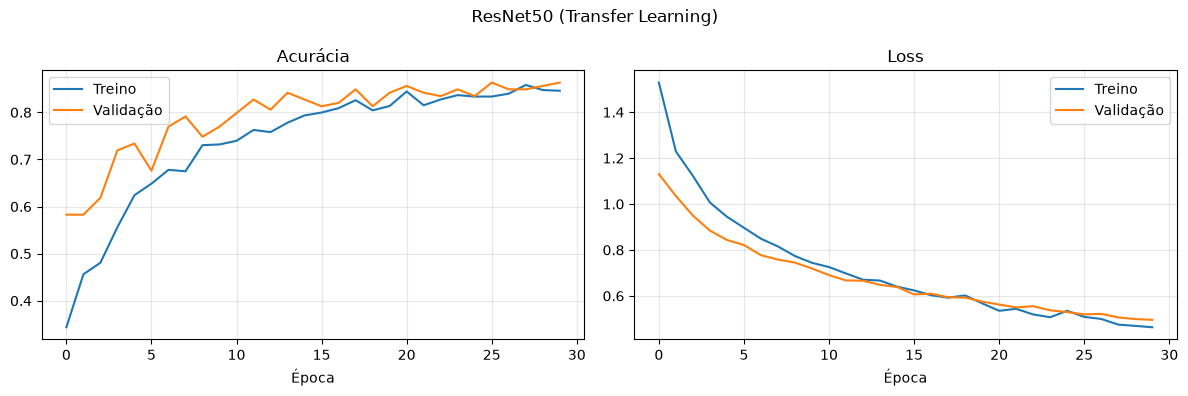

In [14]:
plot_training_history(history, MODEL_TITLE)

## 5. Métricas de avaliação (conjunto de teste)


=== ResNet50 (Transfer Learning) — Teste ===
Acurácia: 0.9214 | Loss: 0.4177

Relatório de classificação (precisão, recall, F1):
                            precision    recall  f1-score   support

batimento_cardiaco_anormal       0.94      0.91      0.93        35
     historico_pos_infarto       0.91      0.77      0.83        26
      infarto_do_miocardio       0.95      0.97      0.96        36
                    normal       0.89      0.98      0.93        43

                  accuracy                           0.92       140
                 macro avg       0.92      0.91      0.91       140
              weighted avg       0.92      0.92      0.92       140



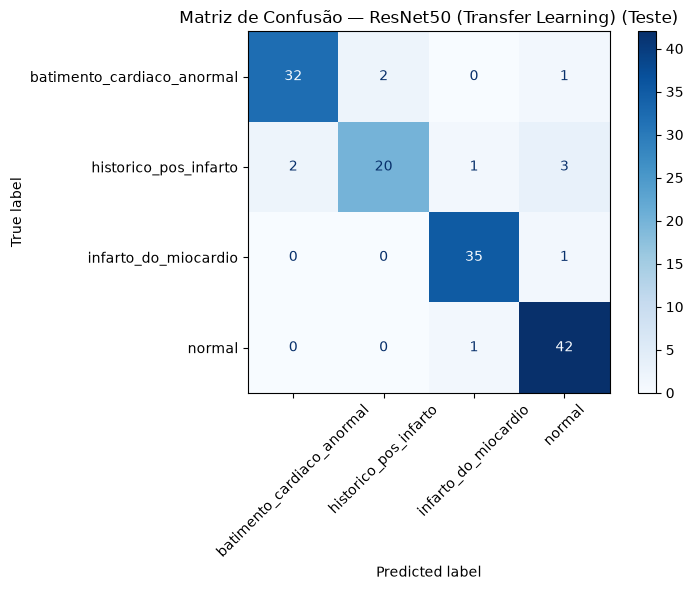

In [15]:
# Avaliação no conjunto de teste (métricas finais)
test_results = evaluate_model(resnet_model, test_ds, "Teste", MODEL_TITLE)

## 6. Comparação rápida CNN vs ResNet50

In [16]:
# Execute também o notebook 02 para comparar. Exemplo de comparação de acurácia no teste:
print("Para comparar modelos, verifique a acurácia impressa na seção de avaliação de cada notebook.")
print("Métricas deste notebook (ResNet50 — Teste):")
print(f"  Acurácia: {test_results['accuracy']:.4f}")

Para comparar modelos, verifique a acurácia impressa na seção de avaliação de cada notebook.
Métricas deste notebook (ResNet50 — Teste):
  Acurácia: 0.9214
